# NB10C — Topic Sentiment Models
## Topic-Sentiment Extension | MSc Dissertation
### Pavlos Papachristos | University of Essex

**Purpose:** Retrain EBM (M2.5-matched) and M3 with topic-specific sentiment features
(credit, monetary_policy, corporate at lags 1–3) added to the Stage 2 feature matrix.
Compare AUROC/AUPRC/Brier/ECE against dissertation baseline.

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss)
from interpret.glassbox import ExplainableBoostingClassifier

TOPIC_DIR = r".\data\processed\topic_sentiment"
DATA_DIR  = r".\data\processed"
FIG_DIR   = r".\figures\topic_sentiment"
os.makedirs(FIG_DIR, exist_ok=True)

# Load merged panel
df = pd.read_csv(os.path.join(TOPIC_DIR, "jst_topic_sentiment_merged.csv"))
print(df.shape)
print("Years:", df["year"].min(), "–", df["year"].max())
print("Countries:", sorted(df["iso"].unique()))

(569, 119)
Years: 1989 – 2020
Countries: ['AUS', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'IRL', 'ITA', 'JPN', 'NLD', 'NOR', 'PRT', 'SWE', 'USA']


In [6]:
# ── Stage 2 feature matrix (2003–2020) ───────────────────────────────────────
# Target variable
TARGET = "crisisjst"   # lowercase — confirmed from df.columns

# Stage 2 window
df_s2 = df[(df["year"] >= 2003) & (df["year"] <= 2020)].copy()
print("Stage 2 rows:", len(df_s2))
print("Crisis events:", df_s2[TARGET].sum())

# Load M3 feature list from dissertation as baseline
m3_features = pd.read_csv(os.path.join(DATA_DIR, "augmented_analysis", "M3_features.csv"))
m3_feature_list = [m3_features.columns[0]] + m3_features.iloc[:, 0].tolist()
print("M3 features extracted:", len(m3_feature_list))  # expect 60
print(m3_feature_list[:5])  # sanity check

Stage 2 rows: 319
Crisis events: 13.0
M3 features extracted: 61
['tloans_lag1_dm', 'tmort_lag1_dm', 'money_lag1_dm', 'ltrate_lag1_dm', 'stir_lag1_dm']


In [3]:
# Check target column name
print([c for c in df.columns if "crisis" in c.lower()])

['crisisjst']


In [4]:
print([c for c in df_s2.columns if 'crisis' in c.lower()])

['crisisjst']


In [11]:
# ── Load topic-sentiment features (NB10B output) ─────────────────────────────
topic_sent = pd.read_csv(os.path.join(DATA_DIR, "topic_sentiment", "jst_topic_sentiment_merged.csv"))
print("Topic sentiment shape:", topic_sent.shape)

# Only merge columns not already in df_s2 (avoid _x/_y duplicates)
new_cols = ["iso", "year"] + [c for c in topic_sent.columns 
                               if c not in df_s2.columns and c not in ("iso", "year")]
df_s2 = df_s2.merge(topic_sent[new_cols], on=["iso", "year"], how="left")
print("df_s2 shape after merge:", df_s2.shape)

# Define topic sentiment feature columns
TOPICS = ["credit", "monetary_policy", "corporate"]
topic_features = [f"{t}_sent_neg_lag{l}" for t in TOPICS for l in [1, 2, 3]]
print("\nTopic sentiment features:", topic_features)

# Check coverage
missing = [f for f in topic_features if f not in df_s2.columns]
if missing:
    print("WARNING — missing from df_s2:", missing)
else:
    print("All topic features present ✓")
    print("Non-null counts:\n", df_s2[topic_features].notna().sum())

Topic sentiment shape: (569, 119)
df_s2 shape after merge: (319, 137)

Topic sentiment features: ['credit_sent_neg_lag1', 'credit_sent_neg_lag2', 'credit_sent_neg_lag3', 'monetary_policy_sent_neg_lag1', 'monetary_policy_sent_neg_lag2', 'monetary_policy_sent_neg_lag3', 'corporate_sent_neg_lag1', 'corporate_sent_neg_lag2', 'corporate_sent_neg_lag3']
All topic features present ✓
Non-null counts:
 credit_sent_neg_lag1              95
credit_sent_neg_lag2              90
credit_sent_neg_lag3              85
monetary_policy_sent_neg_lag1    168
monetary_policy_sent_neg_lag2    164
monetary_policy_sent_neg_lag3    159
corporate_sent_neg_lag1          145
corporate_sent_neg_lag2          141
corporate_sent_neg_lag3          136
dtype: int64


In [8]:
import glob, os
hits = glob.glob(r".\**\jst_topic_sentiment_merged.csv", recursive=True)
print(hits)

['.\\data\\processed\\topic_sentiment\\jst_topic_sentiment_merged.csv']


In [10]:
print([c for c in df_s2.columns if 'sent' in c])

['credit_sent_neg', 'credit_sent_pos', 'monetary_policy_sent_neg', 'monetary_policy_sent_pos', 'corporate_sent_neg', 'corporate_sent_pos', 'credit_sent_neg_lag1_x', 'credit_sent_neg_lag2_x', 'credit_sent_neg_lag3_x', 'monetary_policy_sent_neg_lag1_x', 'monetary_policy_sent_neg_lag2_x', 'monetary_policy_sent_neg_lag3_x', 'corporate_sent_neg_lag1_x', 'corporate_sent_neg_lag2_x', 'corporate_sent_neg_lag3_x', 'credit_sent_neg_lag1_y', 'credit_sent_neg_lag2_y', 'credit_sent_neg_lag3_y', 'monetary_policy_sent_neg_lag1_y', 'monetary_policy_sent_neg_lag2_y', 'monetary_policy_sent_neg_lag3_y', 'corporate_sent_neg_lag1_y', 'corporate_sent_neg_lag2_y', 'corporate_sent_neg_lag3_y']


In [16]:
# ── Build augmented feature matrix ───────────────────────────────────────────
m3_available = [f for f in m3_feature_list if f in df_s2.columns]
print(f"M3 features available in df_s2: {len(m3_available)} / {len(m3_feature_list)}")

aug_features = m3_available + topic_features
print(f"Augmented feature set: {len(aug_features)} features")

# ── Full Stage 2 matrix (no temporal split — use CV) ─────────────────────────
df_model = df_s2.dropna(subset=[TARGET]).copy()
print(f"\nModelling rows: {len(df_model)} | Positives: {df_model[TARGET].sum():.0f}")

X = df_model[aug_features]
y = df_model[TARGET]

# ── Stratified K-Fold ─────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=False)  # shuffle=False preserves temporal order within folds

fold_sizes = [(train_idx.shape[0], test_idx.shape[0], y.iloc[test_idx].sum())
              for train_idx, test_idx in skf.split(X, y)]

print(f"\nStratifiedKFold — {N_SPLITS} folds:")
for i, (tr, te, pos) in enumerate(fold_sizes):
    print(f"  Fold {i+1}: train={tr}, test={te}, test_positives={pos:.0f}")

M3 features available in df_s2: 41 / 61
Augmented feature set: 50 features

Modelling rows: 319 | Positives: 13

StratifiedKFold — 5 folds:
  Fold 1: train=255, test=64, test_positives=2
  Fold 2: train=255, test=64, test_positives=3
  Fold 3: train=255, test=64, test_positives=3
  Fold 4: train=255, test=64, test_positives=3
  Fold 5: train=256, test=63, test_positives=2


In [17]:
# ── Model training — StratifiedKFold CV ──────────────────────────────────────
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from interpret.glassbox import ExplainableBoostingClassifier

results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Impute NaNs with training median (topic sentiment is sparse)
    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    for name, model in [
        ("RF",  RandomForestClassifier(n_estimators=500, max_depth=4,
                                        class_weight="balanced", random_state=42)),
        ("EBM", ExplainableBoostingClassifier(max_bins=128, interactions=5, random_state=42))
    ]:
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]

        results.append({
            "fold":   fold + 1,
            "model":  name,
            "auroc":  roc_auc_score(y_te, proba),
            "auprc":  average_precision_score(y_te, proba),
            "brier":  brier_score_loss(y_te, proba),
        })
        print(f"Fold {fold+1} {name}: AUROC={results[-1]['auroc']:.3f}  "
              f"AUPRC={results[-1]['auprc']:.3f}  Brier={results[-1]['brier']:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
import pandas as pd
res_df = pd.DataFrame(results)
print("\nMean metrics across folds:")
print(res_df.groupby("model")[["auroc","auprc","brier"]].mean().round(3))
print("\nStd across folds:")
print(res_df.groupby("model")[["auroc","auprc","brier"]].std().round(3))

Fold 1 RF: AUROC=0.831  AUPRC=0.543  Brier=0.051
Fold 1 EBM: AUROC=0.839  AUPRC=0.545  Brier=0.023
Fold 2 RF: AUROC=0.913  AUPRC=0.511  Brier=0.041
Fold 2 EBM: AUROC=0.984  AUPRC=0.833  Brier=0.031
Fold 3 RF: AUROC=0.967  AUPRC=0.778  Brier=0.031
Fold 3 EBM: AUROC=0.951  AUPRC=0.750  Brier=0.042
Fold 4 RF: AUROC=0.781  AUPRC=0.244  Brier=0.042
Fold 4 EBM: AUROC=0.721  AUPRC=0.179  Brier=0.046
Fold 5 RF: AUROC=0.959  AUPRC=0.417  Brier=0.030
Fold 5 EBM: AUROC=0.951  AUPRC=0.325  Brier=0.035

Mean metrics across folds:
       auroc  auprc  brier
model                     
EBM    0.889  0.527  0.035
RF     0.890  0.499  0.039

Std across folds:
       auroc  auprc  brier
model                     
EBM    0.109  0.276  0.009
RF     0.081  0.195  0.009


In [18]:
# ── Cell 6: M3-only baseline (no topic sentiment) ────────────────────────────
results_base = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tr, X_te = X[m3_available].iloc[train_idx], X[m3_available].iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    for name, model in [
        ("RF",  RandomForestClassifier(n_estimators=500, max_depth=4,
                                        class_weight="balanced", random_state=42)),
        ("EBM", ExplainableBoostingClassifier(max_bins=128, interactions=5, random_state=42))
    ]:
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]

        results_base.append({
            "fold":  fold + 1,
            "model": name,
            "auroc": roc_auc_score(y_te, proba),
            "auprc": average_precision_score(y_te, proba),
            "brier": brier_score_loss(y_te, proba),
        })
        print(f"Fold {fold+1} {name}: AUROC={results_base[-1]['auroc']:.3f}  "
              f"AUPRC={results_base[-1]['auprc']:.3f}  Brier={results_base[-1]['brier']:.3f}")

# ── Comparison summary ────────────────────────────────────────────────────────
base_df = pd.DataFrame(results_base)
aug_mean  = res_df.groupby("model")[["auroc","auprc","brier"]].mean().round(3)
base_mean = base_df.groupby("model")[["auroc","auprc","brier"]].mean().round(3)

print("\nM3-only baseline (mean across folds):")
print(base_mean)
print("\nAugmented +topic sentiment (mean across folds):")
print(aug_mean)
print("\nDelta (augmented minus baseline):")
print((aug_mean - base_mean).round(3))

Fold 1 RF: AUROC=0.806  AUPRC=0.538  Brier=0.060
Fold 1 EBM: AUROC=0.806  AUPRC=0.538  Brier=0.023
Fold 2 RF: AUROC=0.913  AUPRC=0.529  Brier=0.044
Fold 2 EBM: AUROC=0.995  AUPRC=0.917  Brier=0.027
Fold 3 RF: AUROC=0.967  AUPRC=0.778  Brier=0.031
Fold 3 EBM: AUROC=0.918  AUPRC=0.500  Brier=0.043
Fold 4 RF: AUROC=0.732  AUPRC=0.190  Brier=0.044
Fold 4 EBM: AUROC=0.825  AUPRC=0.462  Brier=0.039
Fold 5 RF: AUROC=0.943  AUPRC=0.611  Brier=0.032
Fold 5 EBM: AUROC=0.902  AUPRC=0.216  Brier=0.033

M3-only baseline (mean across folds):
       auroc  auprc  brier
model                     
EBM    0.889  0.527  0.033
RF     0.872  0.529  0.042

Augmented +topic sentiment (mean across folds):
       auroc  auprc  brier
model                     
EBM    0.889  0.527  0.035
RF     0.890  0.499  0.039

Delta (augmented minus baseline):
       auroc  auprc  brier
model                     
EBM    0.000   0.00  0.002
RF     0.018  -0.03 -0.003


Pre-GFC  (2003–2006): 72 rows | 0 positives
GFC      (2007–2012): 108 rows | 13 positives
Post-GFC (2013–2020): 139 rows | 0 positives

EBM full-sample feature importances (top 10):
term_spread_lag2_dm & ltrate_lag3_dm         0.6549
ltrate_lag3_dm & term_spread_lag3_dm         0.5496
term_spread_lag3_dm                          0.5099
term_spread_lag1_dm                          0.4967
term_spread_lag1_dm & term_spread_lag2_dm    0.4554
term_spread_lag1_dm & ltrate_lag3_dm         0.3303
term_spread_lag1_dm & stir_lag3_dm           0.2896
stir_lag1_dm                                 0.2761
tloans_gr_lag1_dm                            0.2618
term_spread_lag2_dm                          0.2144
dtype: float64

Top topic features by importance: ['monetary_policy_sent_neg_lag3', 'monetary_policy_sent_neg_lag2', 'corporate_sent_neg_lag1']


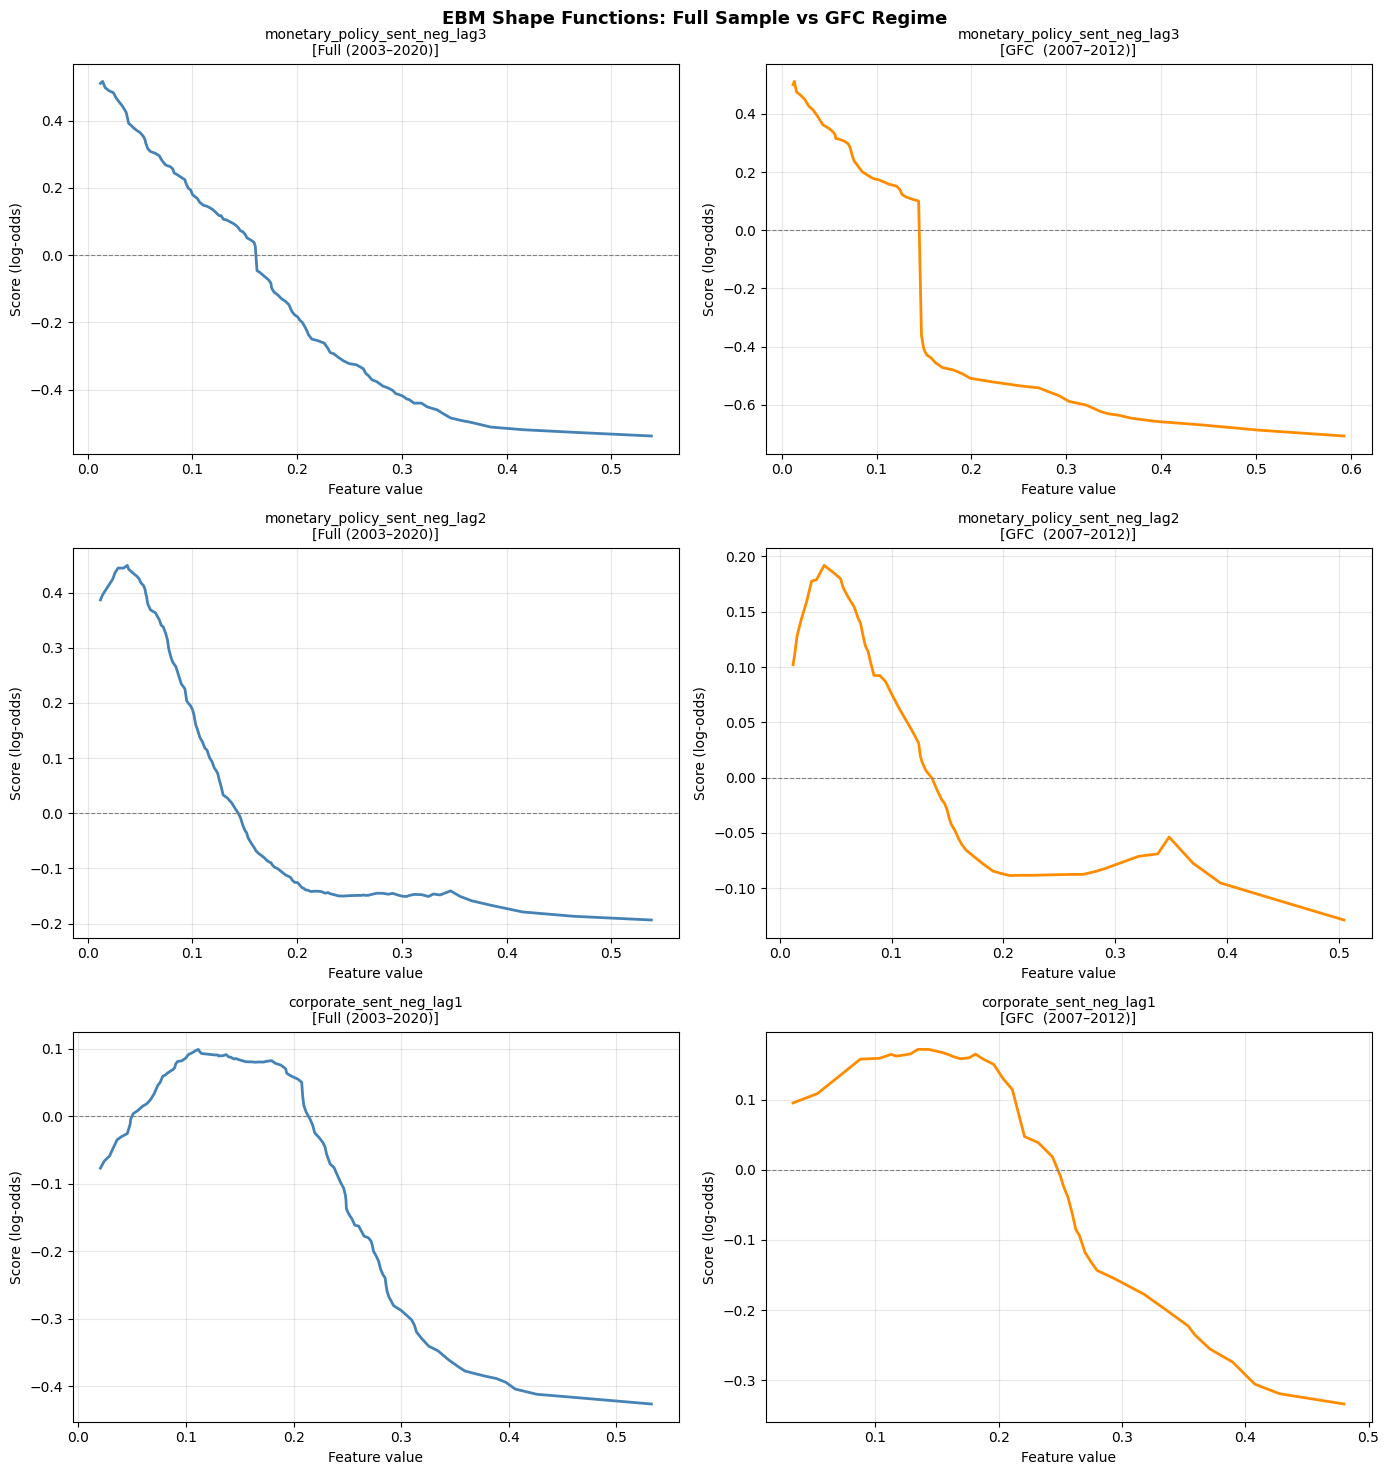

Shape function plot saved.


In [21]:
# ── Cell 7: EBM shape function stability across regimes ──────────────────────
import matplotlib.pyplot as plt

# Define regime splits within 2003–2020
pre_gfc = df_s2[df_s2["year"] <= 2006].dropna(subset=[TARGET])
gfc     = df_s2[(df_s2["year"] >= 2007) & (df_s2["year"] <= 2012)].dropna(subset=[TARGET])
post    = df_s2[df_s2["year"] >= 2013].dropna(subset=[TARGET])

print(f"Pre-GFC  (2003–2006): {len(pre_gfc)} rows | {pre_gfc[TARGET].sum():.0f} positives")
print(f"GFC      (2007–2012): {len(gfc)} rows | {gfc[TARGET].sum():.0f} positives")
print(f"Post-GFC (2013–2020): {len(post)} rows | {post[TARGET].sum():.0f} positives")

# Train EBM on full sample for shape extraction
X_full = df_s2.dropna(subset=[TARGET])[aug_features]
y_full = df_s2.dropna(subset=[TARGET])[TARGET]
X_full_imp = X_full.fillna(X_full.median())

ebm_full = ExplainableBoostingClassifier(max_bins=128, interactions=5, random_state=42)
ebm_full.fit(X_full_imp, y_full)

# Train EBM on GFC regime only
X_gfc = gfc[aug_features].fillna(gfc[aug_features].median())
y_gfc = gfc[TARGET]

ebm_gfc = ExplainableBoostingClassifier(max_bins=128, interactions=5, random_state=42)
ebm_gfc.fit(X_gfc, y_gfc)

print("\nEBM full-sample feature importances (top 10):")
imp = pd.Series(ebm_full.term_importances(), index=ebm_full.term_names_).sort_values(ascending=False)
print(imp.head(10).round(4))

# ── Top topic features by importance ─────────────────────────────────────────
top_topic = [f for f in imp.index if f in topic_features][:3]
print(f"\nTop topic features by importance: {top_topic}")

# ── Plot shape functions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(len(top_topic), 2, figsize=(14, 5 * len(top_topic)))
fig.suptitle("EBM Shape Functions: Full Sample vs GFC Regime", fontsize=13, fontweight="bold")

for row, feat in enumerate(top_topic):
    for col, (ebm, label) in enumerate([(ebm_full, "Full (2003–2020)"),
                                         (ebm_gfc,  "GFC  (2007–2012)")]):
        ax = axes[row, col]
        idx    = ebm.term_names_.index(feat)
        bins   = ebm.bins_[idx][0]
        scores = ebm.term_scores_[idx]

        # Compute bin midpoints and trim padding
        x = (bins[:-1] + bins[1:]) / 2   # midpoints, length = len(bins)-1
        s = scores[1:-1]                  # trim both padding edges
        min_len = min(len(x), len(s))
        x, s = x[:min_len], s[:min_len]

        ax.plot(x, s, color="steelblue" if col == 0 else "darkorange", linewidth=2)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_title(f"{feat}\n[{label}]", fontsize=10)
        ax.set_xlabel("Feature value")
        ax.set_ylabel("Score (log-odds)")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "augmented_analysis", "ebm_shape_topic_regimes.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Shape function plot saved.")

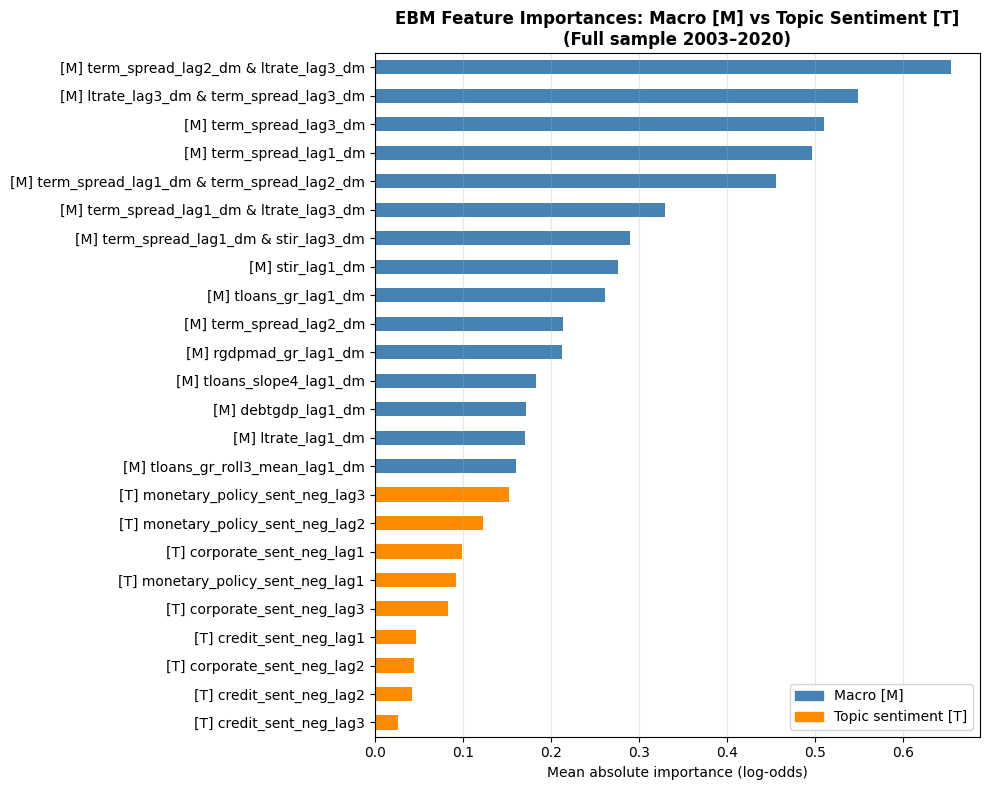

Topic sentiment importances:
monetary_policy_sent_neg_lag3    0.1520
monetary_policy_sent_neg_lag2    0.1232
corporate_sent_neg_lag1          0.0991
monetary_policy_sent_neg_lag1    0.0921
corporate_sent_neg_lag3          0.0836
credit_sent_neg_lag1             0.0464
corporate_sent_neg_lag2          0.0448
credit_sent_neg_lag2             0.0427
credit_sent_neg_lag3             0.0263

Mean topic importance:  0.0789
Mean macro importance:  0.3291
Ratio topic/macro:      0.240


In [22]:
# ── Cell 8: Feature importance summary — macro vs topic sentiment ─────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Split importances into macro and topic
imp_topic = imp[imp.index.isin(topic_features)].sort_values(ascending=False)
imp_macro = imp[~imp.index.isin(topic_features)].sort_values(ascending=False).head(15)

# Combined view: top 15 macro + all topic features
imp_combined = pd.concat([
    imp_macro.rename(lambda x: f"[M] {x}"),
    imp_topic.rename(lambda x: f"[T] {x}")
]).sort_values(ascending=True)

colors = ["steelblue" if x.startswith("[M]") else "darkorange" 
          for x in imp_combined.index]

imp_combined.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("EBM Feature Importances: Macro [M] vs Topic Sentiment [T]\n(Full sample 2003–2020)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Mean absolute importance (log-odds)")
ax.grid(True, axis="x", alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Macro [M]"),
                   Patch(color="darkorange", label="Topic sentiment [T]")],
          loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "augmented_analysis", "ebm_importance_macro_vs_topic.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("Topic sentiment importances:")
print(imp_topic.round(4).to_string())
print(f"\nMean topic importance:  {imp_topic.mean():.4f}")
print(f"Mean macro importance:  {imp_macro.mean():.4f}")
print(f"Ratio topic/macro:      {imp_topic.mean()/imp_macro.mean():.3f}")

In [23]:
# ── Cell 9: Summary table — topic-sentiment extension results ─────────────────
summary = pd.DataFrame({
    "Model": ["RF (M3-only)", "EBM (M3-only)", "RF (Augmented)", "EBM (Augmented)"],
    "Features": [len(m3_available), len(m3_available), len(aug_features), len(aug_features)],
    "AUROC (mean)": [
        base_df[base_df.model=="RF"].auroc.mean(),
        base_df[base_df.model=="EBM"].auroc.mean(),
        res_df[res_df.model=="RF"].auroc.mean(),
        res_df[res_df.model=="EBM"].auroc.mean()
    ],
    "AUROC (std)": [
        base_df[base_df.model=="RF"].auroc.std(),
        base_df[base_df.model=="EBM"].auroc.std(),
        res_df[res_df.model=="RF"].auroc.std(),
        res_df[res_df.model=="EBM"].auroc.std()
    ],
    "AUPRC (mean)": [
        base_df[base_df.model=="RF"].auprc.mean(),
        base_df[base_df.model=="EBM"].auprc.mean(),
        res_df[res_df.model=="RF"].auprc.mean(),
        res_df[res_df.model=="EBM"].auprc.mean()
    ],
    "AUPRC (std)": [
        base_df[base_df.model=="RF"].auprc.std(),
        base_df[base_df.model=="EBM"].auprc.std(),
        res_df[res_df.model=="RF"].auprc.std(),
        res_df[res_df.model=="EBM"].auprc.std()
    ],
    "Brier (mean)": [
        base_df[base_df.model=="RF"].brier.mean(),
        base_df[base_df.model=="EBM"].brier.mean(),
        res_df[res_df.model=="RF"].brier.mean(),
        res_df[res_df.model=="EBM"].brier.mean()
    ],
}).round(3)

print("=" * 75)
print("Topic-Sentiment Extension — Summary Table (StratifiedKFold, n=5)")
print(f"Target: {TARGET} | Stage 2: 2003–2020 | N={len(df_model)} | Positives=13")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)

# Delta rows
print("\nIncremental effect of topic sentiment (Augmented minus M3-only):")
for model in ["RF", "EBM"]:
    base_row = summary[summary.Model == f"{model} (M3-only)"].iloc[0]
    aug_row  = summary[summary.Model == f"{model} (Augmented)"].iloc[0]
    print(f"  {model}: ΔAUROC={aug_row['AUROC (mean)']-base_row['AUROC (mean)']:+.3f}  "
          f"ΔAUPRC={aug_row['AUPRC (mean)']-base_row['AUPRC (mean)']:+.3f}  "
          f"ΔBrier={aug_row['Brier (mean)']-base_row['Brier (mean)']:+.3f}")

# Save
summary.to_csv(os.path.join(DATA_DIR, "augmented_analysis", "topic_sentiment_summary.csv"), index=False)
print("\nSummary table saved.")

Topic-Sentiment Extension — Summary Table (StratifiedKFold, n=5)
Target: crisisjst | Stage 2: 2003–2020 | N=319 | Positives=13
          Model  Features  AUROC (mean)  AUROC (std)  AUPRC (mean)  AUPRC (std)  Brier (mean)
   RF (M3-only)        41         0.872        0.099         0.529        0.214         0.042
  EBM (M3-only)        41         0.889        0.076         0.527        0.252         0.033
 RF (Augmented)        50         0.890        0.081         0.499        0.195         0.039
EBM (Augmented)        50         0.889        0.109         0.527        0.276         0.035

Incremental effect of topic sentiment (Augmented minus M3-only):
  RF: ΔAUROC=+0.018  ΔAUPRC=-0.030  ΔBrier=-0.003
  EBM: ΔAUROC=+0.000  ΔAUPRC=+0.000  ΔBrier=+0.002

Summary table saved.
